## Exercicio 1

In [3]:
## imports

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
x_img = cv2.imread("lena.tif")
cv2.imshow(" OriginalImage " , x_img )
print(x_img.dtype)
print(x_img.shape)
cv2.waitKey(0)
cv2.destroyAllWindows()

uint8
(512, 512, 3)


#### No caso do exercicio 1, a função dtype é utilizada para sabermos que tipo de dados estão na imagem, neste caso sao uint de 8 bits. A função shape é para informar das dimensões da imagem (512,512,3) onde (512,512) indicam as dimensoes em pixeis e o 3 representa as componentes das cores, RBG.


## Exercicio 2

Tamanho do original (lena.tif):  786572 bytes
Tamanho do file1.jpg:  44124 bytes
Tamanho do file2.jpg:  9566 bytes
Taxa de compressão (original/file1): 17.83
Taxa de compressão (original/file2): 82.23
Q80 -> SNR (dBs):  28.468534958720454
Q80 -> PSNR (dBs):  33.606097256534746
Q10 -> SNR (dBs):  22.391956905436455
Q10 -> PSNR (dBs):  27.529519203250743


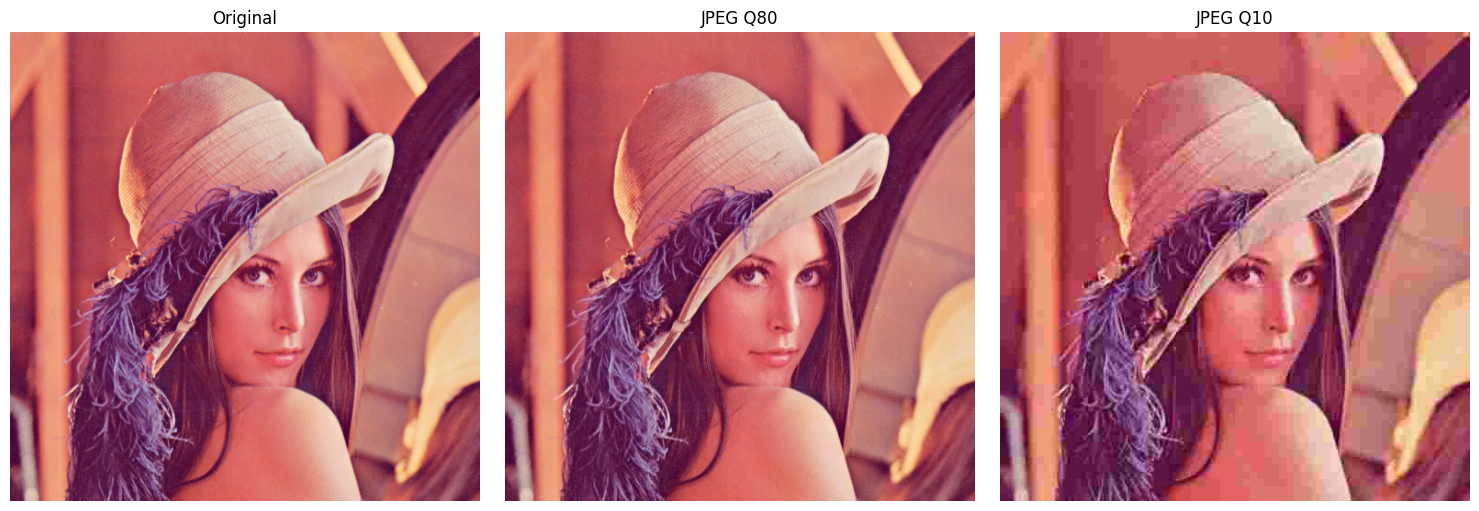

In [5]:
x_img = cv2.imread("lena.tif")

cv2.imwrite("file1.jpg", x_img, ( cv2.IMWRITE_JPEG_QUALITY, 80))
cv2.imwrite("file2.jpg", x_img, ( cv2.IMWRITE_JPEG_QUALITY, 10))

x_img1 = cv2.imread("file1.jpg")
x_img2 = cv2.imread("file2.jpg")

size_org = os.path.getsize("lena.tif")
size_img1 = os.path.getsize("file1.jpg")
size_img2 = os.path.getsize("file2.jpg")
print('Tamanho do original (lena.tif): ', size_org, 'bytes')
print('Tamanho do file1.jpg: ', size_img1, 'bytes')
print('Tamanho do file2.jpg: ', size_img2, 'bytes')

tc1 = size_org / size_img1
tc2 = size_org / size_img2
print('Taxa de compressão (original/file1): %.2f' % tc1)
print('Taxa de compressão (original/file2): %.2f' % tc2)

x_float = x_img*1.
x_img1_float = x_img1*1.
x_img2_float = x_img2*1.

Porg = np.mean(x_float**2)

Perr1 = np.mean((x_float - x_img1_float)**2)
SNR1 = 10*np.log10(Porg/Perr1)
pSNR1 = 10*np.log10(255**2/Perr1)

Perr2 = np.mean((x_float - x_img2_float)**2)
SNR2 = 10*np.log10(Porg/Perr2)
pSNR2 = 10*np.log10(255**2/Perr2)

print('Q80 -> SNR (dBs): ', SNR1)
print('Q80 -> PSNR (dBs): ', pSNR1)
print('Q10 -> SNR (dBs): ', SNR2)
print('Q10 -> PSNR (dBs): ', pSNR2)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(x_img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(x_img1, cv2.COLOR_BGR2RGB))
plt.title('JPEG Q80')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(x_img2, cv2.COLOR_BGR2RGB))
plt.title('JPEG Q10')
plt.axis('off')

plt.tight_layout()
plt.show()

## Exercicio 3

In [6]:
x_img = cv2.imread("lena.tif")
x_img_g = cv2.cvtColor(x_img,cv2.COLOR_BGR2GRAY)
cv2.imshow("GrayImage",x_img_g)
cv2.waitKey(0)
cv2.destroyAllWindows()
qual = 1
cv2.imwrite('file3_%d.bmp' % qual, x_img_g)

Size_org= os.path.getsize('lena.tif')
Size_jpg = os.path.getsize('file3_%d.bmp'%qual)
print('Tamanho original: ', Size_org)
print('Tamanho da imagem bmp: ', Size_jpg)

Tamanho original:  786572
Tamanho da imagem bmp:  263222


## Exercicio 4

C:\Users\marga\AppData\Local\Temp\ipykernel_5484\738917996.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(x_img_g.ravel(),256,[0,256])


Numero de niveis diferentes de cinzento: 215


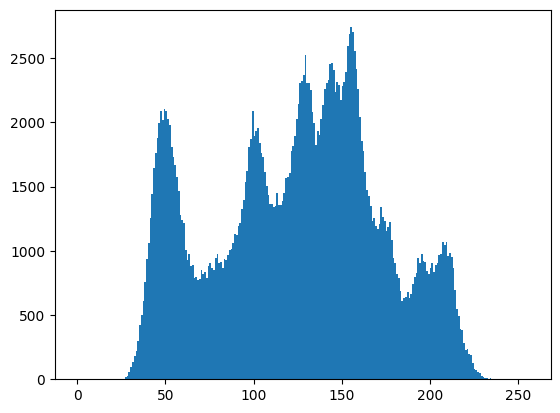

In [8]:
plt.hist(x_img_g.ravel(),256,[0,256])
niveis = np.unique(x_img_g).size
print("Numero de niveis diferentes de cinzento:", niveis)

## Exercicio 5

In [ ]:

plt.figure( figsize =(20 ,10))
plt.subplot(211)
I1 =( Igray %2)*255
plt.imshow(I1 , cmap = "gray")
plt.axis( "off")
plt.title( "bit 1")
plt.subplot(212)
I2 =(( Igray >>1)%2)*255
plt.imshow(I2 , cmap = "gray")
plt.axis( "off")
plt.title( "bit 2")

## Exercicio 6

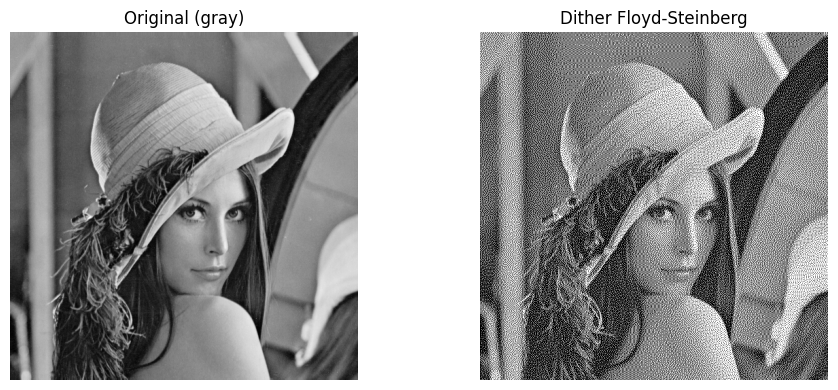

In [7]:
def find_closest_palette_color(oldpixel):
    return 255.0 if oldpixel >= 128.0 else 0.0

def dither(x):
    pixels = x.astype(np.float32).copy()
    h, w = pixels.shape

    for y in range(h):
        for x in range(w):
            oldpixel = pixels[y, x]
            newpixel = find_closest_palette_color(oldpixel)
            pixels[y, x] = newpixel
            quant_error = oldpixel - newpixel

            if x + 1 < w:
                pixels[y, x + 1] = pixels[y, x + 1] + quant_error * 7.0 / 16.0
            if y + 1 < h and x - 1 >= 0:
                pixels[y + 1, x - 1] = pixels[y + 1, x - 1] + quant_error * 3.0 / 16.0
            if y + 1 < h:
                pixels[y + 1, x] = pixels[y + 1, x] + quant_error * 5.0 / 16.0
            if y + 1 < h and x + 1 < w:
                pixels[y + 1, x + 1] = pixels[y + 1, x + 1] + quant_error * 1.0 / 16.0

    return pixels.astype(np.uint8)

if 'x_img_g' not in globals():
    if 'x_img' not in globals():
        x_img = cv2.imread('lena.tif')
    x_img_g = cv2.cvtColor(x_img, cv2.COLOR_BGR2GRAY)

y = dither(x_img_g)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(x_img_g, cmap='gray')
plt.title('Original (gray)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(y, cmap='gray')
plt.title('Dither Floyd-Steinberg')
plt.axis('off')
plt.tight_layout()
plt.show()

## Exercicio 7

## Exercicio 8

## Exercicio 9
### alinea a.